In [1]:
#%pip install -U pandasai
#%pip install -U pandasai-litellm
#%pip install -U google-generativeai

#%pip install -U langchain
#%pip install -U langchain-experimental
#%pip install -U langchain-google-genai
#%pip install tabulate
#%pip install python-dotenv

In [2]:
# =========================
# 1. IMPORT LIBRARIES
# =========================

import os
import shutil
import sys
from dotenv import load_dotenv

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    fbeta_score
)

from openpyxl import Workbook
from openpyxl.styles import Font
from openpyxl.styles import PatternFill
from openpyxl.styles import Alignment
from openpyxl.utils import get_column_letter

import pandasai
from pandasai import SmartDataframe
from pandasai import llm
from pandasai_litellm.litellm import LiteLLM

import langchain
import langchain_experimental
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_experimental.agents import create_pandas_dataframe_agent

import importlib.metadata

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 150)
plt.style.use("default")

# ============================================================
# VISUALIZATION CONFIGURATION
# ============================================================

sns.set_theme(
    style="whitegrid",
    palette="colorblind"
)

FIG_WIDTH = 10
FIG_HEIGHT = 6

EXPORT_DPI = 150


C:\Users\nikde\AppData\Local\Temp\ipykernel_15384\2139002430.py:48: DeprecationWarning: `langchain-experimental` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-experimental/issues/87 for details.
  import langchain_experimental


In [3]:
# check available disk space

total, used, free = shutil.disk_usage("C:\\")
print(f"Free Space: {free / (1024**3):.2f} GB")

Free Space: 0.54 GB


In [4]:
# Check if .env file exists

print("Current directory:", os.getcwd())
print("Files in current directory:")
print(os.listdir())

Current directory: C:\Users\nikde\Documents\Grow Data Skills\Class 10
Files in current directory:
['.env', '.ipynb_checkpoints', 'AI Loan Analytics.ipynb', 'AI_Assisted_Coding.ipynb', 'AI_Python_Analytics.pdf', 'Assignment_Problem_Statement.docx', 'Average Interest Rate by Risk Grade.png', 'Average Loan Amount by Risk Grade.png', 'bank_loan_data.csv', 'Case_Study_Pipeline.ipynb', 'clean_loan_data.csv', 'confusion_matrix.png', 'Correlation Heatmap.png', 'credit_score_distribution.png', 'customer_churn.csv', 'data_quality_report.csv', 'Default Rate by Employment Type.png', 'Default Rate by Loan Purpose.png', 'Default Rate by Risk Grade.png', 'ecommerce_orders.csv', 'eda_charts.png', 'exports', 'loan_analytics_solution.py', 'loan_portfolio_analytics_report.xlsx', 'Monthly Loan Applications.png', 'pandasai.log', 'README.md', 'requirements.txt', 'threshold_tradeoff_curve.png', 'Transcript_ai_da_10.vtt']


In [5]:
# clear space on disk if it is less
# !{sys.executable} -m pip cache purge
# !{sys.executable} -m pip cache info

In [6]:
print(np.__version__)
print(pd.__version__)

1.26.4
2.3.3


In [7]:
print(dir(pandasai.llm))

['LLM', '__all__', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', 'base']


In [8]:
print(pandasai.__version__)

<module 'pandasai.__version__' from 'C:\\Users\\nikde\\anaconda3\\envs\\loan_ai\\Lib\\site-packages\\pandasai\\__version__.py'>


In [9]:
print(dir(pandasai))

['APIKeyManager', 'Agent', 'BytesIO', 'Column', 'ConfigManager', 'DataFrame', 'DatasetLoader', 'DatasetNotFound', 'Hashable', 'InvalidConfigError', 'List', 'Optional', 'Relation', 'Sandbox', 'SemanticLayerSchema', 'SkillsManager', 'SmartDataframe', 'SmartDatalake', 'Source', 'Transformation', 'Union', 'VirtualDataFrame', '__all__', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '__version__', '_current_agent', 'agent', 'annotations', 'api_key', 'chat', 'config', 'constants', 'core', 'create', 'data_loader', 'dataframe', 'ee', 'exceptions', 'find_project_root', 'follow_up', 'get_table_name_from_path', 'get_validated_dataset_path', 'helpers', 'llm', 'load', 'os', 'pd', 'query_builders', 'read_csv', 'read_excel', 'sandbox', 'sanitize_sql_table_name', 'sanitize_sql_table_name_lowercase', 'skill', 'skills', 'smart_dataframe', 'smart_datalake', 'transform_dash_to_underscore', 'vectorstores']


In [10]:
print(importlib.metadata.version("pandasai"))

3.0.0


In [11]:
print(sys.version)

3.11.15 | packaged by Anaconda, Inc. | (main, Jun 11 2026, 15:12:53) [MSC v.1942 64 bit (AMD64)]


In [12]:
print(sys.executable)

C:\Users\nikde\anaconda3\envs\loan_ai\python.exe


In [13]:
!pip --version

pip 26.1.1 from C:\Users\nikde\anaconda3\envs\loan_ai\Lib\site-packages\pip (python 3.11)



In [14]:
!pip list | findstr pandasai

pandasai                     3.0.0
pandasai-litellm             0.0.1


In [15]:
# =========================
# 2. LOAD DATASET
# =========================

file_path = "bank_loan_data.csv"

df = pd.read_csv(
    file_path,
    parse_dates=["application_date"]
)


C:\Users\nikde\AppData\Local\Temp\ipykernel_15384\256595470.py:7: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df = pd.read_csv(


In [16]:
# ============================================================
# TASK 1: DATA LOADING & QUALITY AUDIT
# Loan Portfolio Risk Analytics & Default Prediction Pipeline
# ============================================================

# =========================
# 3. BASIC INSPECTION
# =========================

print("=" * 60)
print("DATASET SHAPE")
print("=" * 60)
print(df.shape)

print("\n" + "=" * 60)
print("BASIC INFO")
print("=" * 60)
print(df.info())

print("\n" + "=" * 60)
print("FIRST 5 ROWS")
print("=" * 60)
print(df.head())


DATASET SHAPE
(1200, 21)

BASIC INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   application_id         1200 non-null   object        
 1   application_date       1200 non-null   datetime64[ns]
 2   branch_id              1200 non-null   object        
 3   state                  1200 non-null   object        
 4   applicant_age          1200 non-null   int64         
 5   annual_income          1127 non-null   float64       
 6   employment_type        1200 non-null   object        
 7   employment_years       1158 non-null   float64       
 8   credit_score           1149 non-null   float64       
 9   existing_debt_balance  1200 non-null   float64       
 10  num_credit_lines       1200 non-null   int64         
 11  num_prev_loans         1200 non-null   int64         
 12  prev_defaults          12

In [17]:

# =========================
# 4. NULL VALUE ANALYSIS
# =========================

null_summary = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
      .reset_index()
)

null_summary.columns = ["Column", "Null_Count"]

print("\n" + "=" * 60)
print("NULL VALUES SUMMARY")
print("=" * 60)
print(null_summary)



NULL VALUES SUMMARY
                   Column  Null_Count
0           annual_income          73
1            credit_score          51
2        employment_years          42
3          application_id           0
4           prev_defaults           0
5              risk_grade           0
6          debt_to_income           0
7         monthly_payment           0
8           interest_rate           0
9        loan_term_months           0
10           loan_purpose           0
11            loan_amount           0
12       num_credit_lines           0
13         num_prev_loans           0
14       application_date           0
15  existing_debt_balance           0
16        employment_type           0
17          applicant_age           0
18                  state           0
19              branch_id           0
20           loan_default           0


In [18]:
# =========================
# 5. DUPLICATE APPLICATION IDs
# =========================

duplicate_count = (
    df["application_id"]
    .duplicated()
    .sum()
)

print("\n" + "=" * 60)
print("DUPLICATE APPLICATION IDs")
print("=" * 60)
print(f"Duplicate Application IDs: {duplicate_count}")


DUPLICATE APPLICATION IDs
Duplicate Application IDs: 36


In [19]:
# =========================
# 6. IMPOSSIBLE VALUE CHECKS
# =========================

# Negative loan amounts
negative_loan_count = (
    df["loan_amount"] < 0
).sum()

# Credit score outside valid range
invalid_credit_score_count = (
    (df["credit_score"] < 300) |
    (df["credit_score"] > 850)
).sum()

# Age outside valid range
invalid_age_count = (
    (df["applicant_age"] < 18) |
    (df["applicant_age"] > 100)
).sum()

print("\n" + "=" * 60)
print("IMPOSSIBLE VALUE CHECKS")
print("=" * 60)

print(f"Negative Loan Amounts      : {negative_loan_count}")
print(f"Invalid Credit Scores      : {invalid_credit_score_count}")
print(f"Invalid Applicant Ages     : {invalid_age_count}")



IMPOSSIBLE VALUE CHECKS
Negative Loan Amounts      : 34
Invalid Credit Scores      : 0
Invalid Applicant Ages     : 0


In [20]:
# =========================
# 7. DATA QUALITY SUMMARY
# =========================

quality_summary = pd.DataFrame({
    "Column_Name": df.columns,
    "Null_Count": df.isnull().sum().values,
    "Null_%": (df.isnull().mean() * 100).round(2).values,
    "Data_Type": df.dtypes.astype(str).values
})

quality_summary["Flag"] = ""

# Duplicate flag
quality_summary.loc[
    quality_summary["Column_Name"] == "application_id",
    "Flag"
] += "DUPLICATE"

# Negative values flag
quality_summary.loc[
    quality_summary["Column_Name"] == "loan_amount",
    "Flag"
] += "NEGATIVE"

# Out of range flags
quality_summary.loc[
    quality_summary["Column_Name"] == "credit_score",
    "Flag"
] += "OUT_OF_RANGE"

quality_summary.loc[
    quality_summary["Column_Name"] == "applicant_age",
    "Flag"
] += "OUT_OF_RANGE"

print("\n" + "=" * 60)
print("DATA QUALITY SUMMARY")
print("=" * 60)
print(quality_summary)


DATA QUALITY SUMMARY
              Column_Name  Null_Count  Null_%       Data_Type          Flag
0          application_id           0    0.00          object     DUPLICATE
1        application_date           0    0.00  datetime64[ns]              
2               branch_id           0    0.00          object              
3                   state           0    0.00          object              
4           applicant_age           0    0.00           int64  OUT_OF_RANGE
5           annual_income          73    6.08         float64              
6         employment_type           0    0.00          object              
7        employment_years          42    3.50         float64              
8            credit_score          51    4.25         float64  OUT_OF_RANGE
9   existing_debt_balance           0    0.00         float64              
10       num_credit_lines           0    0.00           int64              
11         num_prev_loans           0    0.00           int64     

In [21]:
def profile_dataframe(df):
    """
    Generate a reusable data quality profiling report.

    Parameters
    ----------
    df : pandas.DataFrame

    Returns
    -------
    pandas.DataFrame
        Quality summary table containing:
        - Column Name
        - Null Count
        - Null %
        - Data Type
        - Flag
    """

    summary = pd.DataFrame({
        "Column_Name": df.columns,
        "Null_Count": df.isnull().sum().values,
        "Null_%": (df.isnull().mean() * 100).round(2).values,
        "Data_Type": df.dtypes.astype(str).values
    })

    summary["Flag"] = ""

    # ---------------------
    # Duplicate ID Check
    # ---------------------
    if "application_id" in df.columns:
        duplicate_count = df["application_id"].duplicated().sum()

        if duplicate_count > 0:
            summary.loc[
                summary["Column_Name"] == "application_id",
                "Flag"
            ] += "DUPLICATE"

    # ---------------------
    # Loan Amount Check
    # ---------------------
    if "loan_amount" in df.columns:

        if (df["loan_amount"] < 0).sum() > 0:

            summary.loc[
                summary["Column_Name"] == "loan_amount",
                "Flag"
            ] += "NEGATIVE"

    # ---------------------
    # Credit Score Check
    # ---------------------
    if "credit_score" in df.columns:

        if (
            ((df["credit_score"] < 300) |
             (df["credit_score"] > 850))
        ).sum() > 0:

            summary.loc[
                summary["Column_Name"] == "credit_score",
                "Flag"
            ] += "OUT_OF_RANGE"

    # ---------------------
    # Age Check
    # ---------------------
    if "applicant_age" in df.columns:

        if (
            ((df["applicant_age"] < 18) |
             (df["applicant_age"] > 100))
        ).sum() > 0:

            summary.loc[
                summary["Column_Name"] == "applicant_age",
                "Flag"
            ] += "OUT_OF_RANGE"

    return summary

In [22]:
quality_report = profile_dataframe(df)

print(quality_report)

# Export if needed
quality_report.to_csv(
    "data_quality_report.csv",
    index=False
)

              Column_Name  Null_Count  Null_%       Data_Type       Flag
0          application_id           0    0.00          object  DUPLICATE
1        application_date           0    0.00  datetime64[ns]           
2               branch_id           0    0.00          object           
3                   state           0    0.00          object           
4           applicant_age           0    0.00           int64           
5           annual_income          73    6.08         float64           
6         employment_type           0    0.00          object           
7        employment_years          42    3.50         float64           
8            credit_score          51    4.25         float64           
9   existing_debt_balance           0    0.00         float64           
10       num_credit_lines           0    0.00           int64           
11         num_prev_loans           0    0.00           int64           
12          prev_defaults           0    0.00      

In [23]:
# ============================================================
# TASK 2: DATA CLEANING PIPELINE
# Loan Portfolio Risk Analytics & Default Prediction Pipeline
# ============================================================

# ============================================================
# CLEANING FUNCTIONS
# ============================================================

def remove_duplicate_applications(df):
    """
    Remove duplicate application IDs.
    Keep the first occurrence.
    """

    df = df.drop_duplicates(
        subset="application_id",
        keep="first"
    )

    return df


def drop_missing_risk_fields(df):
    """
    Remove rows where annual_income or credit_score is missing.
    These fields are required for risk assessment.
    """

    df = df.dropna(
        subset=["annual_income", "credit_score"]
    )

    return df


def impute_employment_years(df):
    """
    Fill missing employment_years using
    median employment years within each employment_type.
    """

    df["employment_years"] = (
        df.groupby("employment_type")["employment_years"]
          .transform(
              lambda x: x.fillna(x.median())
          )
    )

    return df


def remove_negative_loan_amounts(df):
    """
    Remove rows with negative loan amounts.
    """

    df = df[df["loan_amount"] >= 0]

    return df


def standardize_employment_type(df):
    """
    Clean employment_type values:
    - Remove leading/trailing spaces
    - Convert to title case
    """

    df["employment_type"] = (
        df["employment_type"]
        .astype(str)
        .str.strip()
        .str.title()
    )

    return df


def validate_employment_types(df):
    """
    Verify only expected employment types exist.
    """

    expected_values = {
        "Salaried",
        "Self-Employed",
        "Contract",
        "Part-Time",
        "Unemployed"
    }

    actual_values = set(
        df["employment_type"].dropna().unique()
    )

    unexpected_values = (
        actual_values - expected_values
    )

    print("\nEmployment Type Validation")
    print("-" * 40)

    if len(unexpected_values) == 0:
        print("PASS: Only expected employment types found")
    else:
        print("FAIL: Unexpected values found")
        print(unexpected_values)

    # return unexpected_values


In [24]:
# ============================================================
# STORE BEFORE METRICS
# ============================================================

rows_before = len(df)

duplicates_before = (
    df["application_id"]
    .duplicated()
    .sum()
)

nulls_before = (
    df.isnull()
      .sum()
      .sum()
)

In [25]:
# ============================================================
# APPLY CLEANING PIPELINE
# ============================================================

df_clean = remove_duplicate_applications(df)

df_clean = drop_missing_risk_fields(df_clean)

df_clean = standardize_employment_type(df_clean)

df_clean = impute_employment_years(df_clean)

df_clean = remove_negative_loan_amounts(df_clean)

validate_employment_types(df_clean)



Employment Type Validation
----------------------------------------
PASS: Only expected employment types found


In [26]:
# ============================================================
# AFTER METRICS
# ============================================================

rows_after = len(df_clean)

duplicates_after = (
    df_clean["application_id"]
    .duplicated()
    .sum()
)

nulls_after = (
    df_clean.isnull()
            .sum()
            .sum()
)


In [27]:
# ============================================================
# BEFORE / AFTER SUMMARY
# ============================================================

summary = pd.DataFrame({
    "Metric": [
        "Rows",
        "Duplicate Application IDs",
        "Total Null Values"
    ],
    "Before": [
        rows_before,
        duplicates_before,
        nulls_before
    ],
    "After": [
        rows_after,
        duplicates_after,
        nulls_after
    ]
})

summary["Difference"] = (
    summary["Before"] -
    summary["After"]
)

print("\n")
print("=" * 70)
print("DATA CLEANING SUMMARY")
print("=" * 70)

print(summary)



DATA CLEANING SUMMARY
                      Metric  Before  After  Difference
0                       Rows    1200   1016         184
1  Duplicate Application IDs      36      0          36
2          Total Null Values     166      0         166


In [28]:
# ============================================================
# SAVE CLEAN DATASET
# ============================================================

df_clean.to_csv(
    "clean_loan_data.csv",
    index=False
)

print("\nClean dataset saved successfully.")
print("Filename: clean_loan_data.csv")


Clean dataset saved successfully.
Filename: clean_loan_data.csv


In [29]:
def clean_loan_data(df, save_file=False):
    """
    Complete loan data cleaning pipeline.

    Parameters
    ----------
    df : pd.DataFrame
        Raw loan data.

    save_file : bool, default=False
        Whether to save cleaned data to CSV.

    Returns
    -------
    pd.DataFrame
        Cleaned dataframe.
    """

    df = df.copy()

    # =====================================
    # BEFORE METRICS
    # =====================================

    rows_before = len(df)

    duplicates_before = (
        df["application_id"]
        .duplicated()
        .sum()
    )

    nulls_before = (
        df.isnull()
          .sum()
          .sum()
    )

    # =====================================
    # CLEANING STEP 1
    # Remove duplicate application IDs
    # =====================================

    df = df.drop_duplicates(
        subset="application_id",
        keep="first"
    )

    # =====================================
    # CLEANING STEP 2
    # Drop required null fields
    # =====================================

    df = df.dropna(
        subset=[
            "annual_income",
            "credit_score"
        ]
    )

    # =====================================
    # CLEANING STEP 3
    # Standardize employment type
    # =====================================

    df["employment_type"] = (
        df["employment_type"]
        .str.strip()
        .str.title()
    )

    # =====================================
    # CLEANING STEP 4
    # Impute employment years
    # =====================================

    df["employment_years"] = (
        df.groupby("employment_type")["employment_years"]
          .transform(
              lambda x: x.fillna(x.median())
          )
    )

    # =====================================
    # CLEANING STEP 5
    # Remove negative loan amounts
    # =====================================

    df = df[df["loan_amount"] >= 0]

    # =====================================
    # VALIDATION
    # =====================================

    expected_values = {
        "Salaried",
        "Self-Employed",
        "Contract",
        "Part-Time",
        "Unemployed"
    }

    actual_values = set(
        df["employment_type"]
        .dropna()
        .unique()
    )

    unexpected_values = (
        actual_values -
        expected_values
    )

    print("\nEmployment Type Validation")
    print("-" * 40)

    if len(unexpected_values) == 0:
        print("PASS: Only expected employment types found")
    else:
        print("FAIL: Unexpected values found")
        print(unexpected_values)

    # =====================================
    # AFTER METRICS
    # =====================================

    rows_after = len(df)

    duplicates_after = (
        df["application_id"]
        .duplicated()
        .sum()
    )

    nulls_after = (
        df.isnull()
          .sum()
          .sum()
    )

    # =====================================
    # CLEANING SUMMARY
    # =====================================

    summary = pd.DataFrame({
        "Metric": [
            "Rows",
            "Duplicate Application IDs",
            "Total Null Values"
        ],
        "Before": [
            rows_before,
            duplicates_before,
            nulls_before
        ],
        "After": [
            rows_after,
            duplicates_after,
            nulls_after
        ]
    })

    summary["Difference"] = (
        summary["Before"] -
        summary["After"]
    )

    print("\nDATA CLEANING SUMMARY")
    print(summary)

    # =====================================
    # OPTIONAL SAVE
    # =====================================

    if save_file:
        df.to_csv(
            "clean_loan_data.csv",
            index=False
        )
        print("\nSaved: clean_loan_data.csv")

    return df

In [30]:
df = pd.read_csv(
    "bank_loan_data.csv",
    parse_dates=["application_date"]
)

df_clean = clean_loan_data(
    df,
    save_file=True
)


Employment Type Validation
----------------------------------------
PASS: Only expected employment types found

DATA CLEANING SUMMARY
                      Metric  Before  After  Difference
0                       Rows    1200   1016         184
1  Duplicate Application IDs      36      0          36
2          Total Null Values     166      0         166

Saved: clean_loan_data.csv


C:\Users\nikde\AppData\Local\Temp\ipykernel_15384\2117874938.py:1: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df = pd.read_csv(


In [31]:
numeric_cols = df_clean.select_dtypes(
    include=np.number
).columns

numeric_df = df_clean[numeric_cols]

In [32]:
numeric_df.head()

,applicant_age,annual_income,employment_years,credit_score,existing_debt_balance,num_credit_lines,num_prev_loans,prev_defaults,loan_amount,loan_term_months,interest_rate,monthly_payment,debt_to_income,loan_default
0,43,66028.34,16.5,591.0,1517.18,15,1,1,20344.09,24,5.75,899.37,0.1635,1
1,28,29553.04,6.5,782.0,50109.80,6,0,0,91753.90,24,5.09,4029.07,1.6360,0
2,35,65230.92,6.2,538.0,125598.91,9,2,0,126641.80,48,7.73,3075.67,0.5658,1
4,67,21558.62,4.6,751.0,18904.80,12,1,0,69057.69,84,5.65,997.29,0.5551,1
5,61,99119.81,4.1,794.0,120952.68,4,1,0,58970.30,12,4.46,5033.72,0.6094,0


In [33]:
# ============================================================
# HELPER FUNCTION
# ============================================================

def default_rate_by_category(df, column):
    """
    Calculate default rate (%) by category.
    """

    result = (
        df.groupby(column)["loan_default"]
          .mean()
          .mul(100)
          .sort_values(ascending=False)
          .reset_index(name="default_rate_pct")
    )

    return result

         loan_purpose  default_rate_pct
0            Personal         43.269231
1           Auto Loan         41.304348
2            Business         40.145985
3             Medical         38.518519
4       Home Purchase         34.745763
5  Debt Consolidation         34.166667
6    Home Improvement         34.057971
7           Education         33.333333


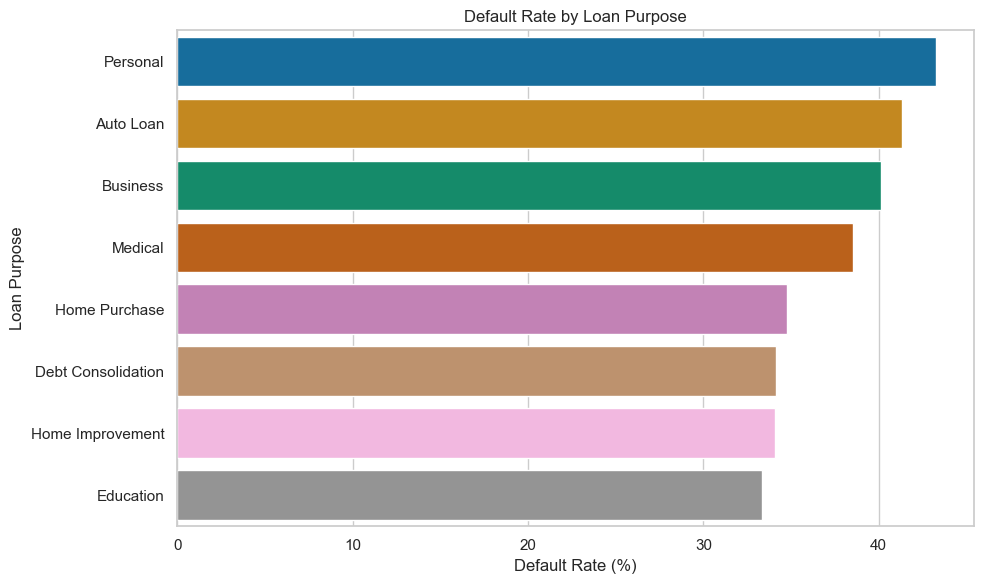

In [34]:
# Analysis 13 — Default Rate by Loan Purpose
# ============================================================
# BUSINESS QUESTION:
# Which loan purposes experience the highest default rates?
# ============================================================

purpose_default = default_rate_by_category(
    df_clean,
    "loan_purpose"
)

print(purpose_default)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=purpose_default,
    x="default_rate_pct",
    y="loan_purpose"
)

plt.title("Default Rate by Loan Purpose")
plt.xlabel("Default Rate (%)")
plt.ylabel("Loan Purpose")

plt.tight_layout()

plt.savefig(
    "Default Rate by Loan Purpose.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

  risk_grade  default_rate_pct
0          E         60.365854
1          D         46.428571
2          C         34.674923
3          B         24.725275
4          A         16.260163


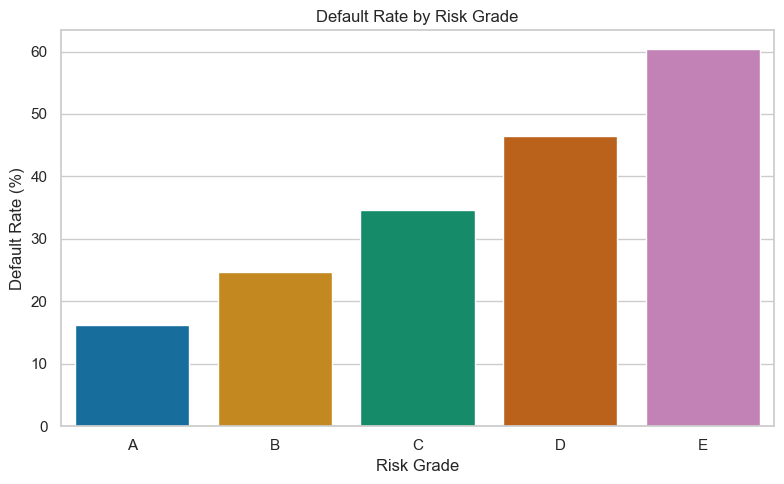

In [35]:
# Analysis 14 — Default Rate by Risk Grade
# ============================================================
# BUSINESS QUESTION:
# Does the internal risk grading system align with actual defaults?
# ============================================================

grade_default = default_rate_by_category(
    df_clean,
    "risk_grade"
)

print(grade_default)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=grade_default,
    x="risk_grade",
    y="default_rate_pct",
    order=["A", "B", "C", "D", "E"]
)

plt.title("Default Rate by Risk Grade")
plt.xlabel("Risk Grade")
plt.ylabel("Default Rate (%)")

plt.tight_layout()

plt.savefig(
    "Default Rate by Risk Grade.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

C:\Users\nikde\anaconda3\envs\loan_ai\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\nikde\anaconda3\envs\loan_ai\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


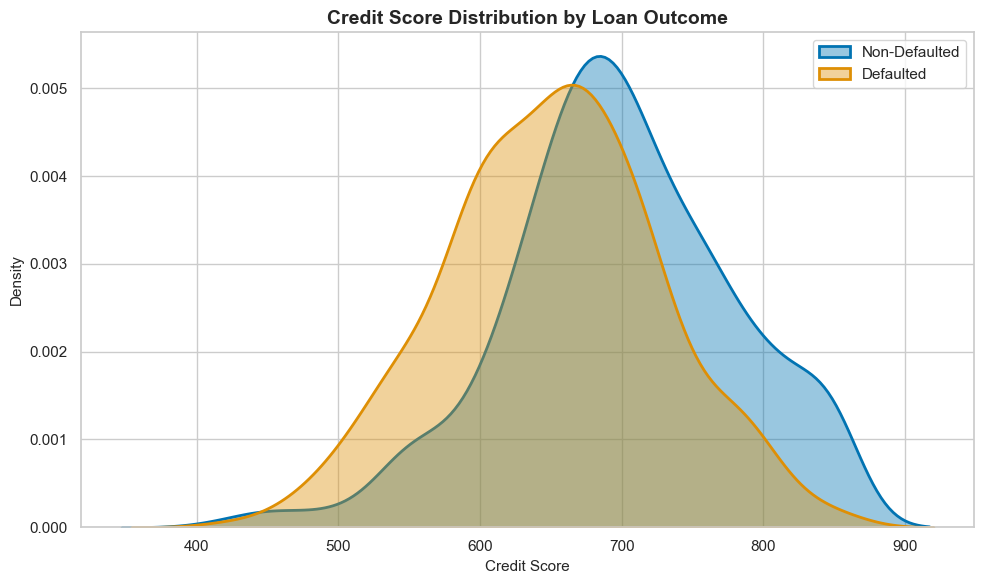

In [36]:
# ============================================================
# ANALYSIS 15
# CREDIT SCORE DISTRIBUTION
# ============================================================
#
# BUSINESS QUESTION:
# How does credit score differ between borrowers
# who defaulted and those who successfully repaid?
#
# VISUALIZATION:
# Overlapping Kernel Density Estimate (KDE) Plot
#
# REASON:
# KDE provides a smoother comparison than a histogram
# and helps identify shifts in credit score distributions.
# ============================================================

plt.figure(
    figsize=(10, 6)
)

# ------------------------------------------------------------
# Non-Defaulted Borrowers
# ------------------------------------------------------------

sns.kdeplot(
    data=df_clean[df_clean["loan_default"] == 0],
    x="credit_score",
    fill=True,
    alpha=0.40,
    linewidth=2,
    label="Non-Defaulted"
)

# ------------------------------------------------------------
# Defaulted Borrowers
# ------------------------------------------------------------

sns.kdeplot(
    data=df_clean[df_clean["loan_default"] == 1],
    x="credit_score",
    fill=True,
    alpha=0.40,
    linewidth=2,
    label="Defaulted"
)

# ------------------------------------------------------------
# Chart Formatting
# ------------------------------------------------------------

plt.title(
    "Credit Score Distribution by Loan Outcome",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel(
    "Credit Score",
    fontsize=11
)

plt.ylabel(
    "Density",
    fontsize=11
)

plt.legend()

plt.tight_layout()

# ------------------------------------------------------------
# Export Figure
# ------------------------------------------------------------

plt.savefig(
    "credit_score_distribution.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [37]:
print(
    df_clean.groupby("loan_default")["credit_score"]
            .describe()
)

              count        mean        std    min     25%    50%     75%    max
loan_default                                                                   
0             636.0  697.764151  81.389978  414.0  649.75  695.0  754.00  850.0
1             380.0  650.447368  76.697328  424.0  598.00  653.0  701.25  850.0



Top 3 Features Correlated with Loan Default
credit_score     0.276452
interest_rate    0.266178
prev_defaults    0.160539
Name: loan_default, dtype: float64


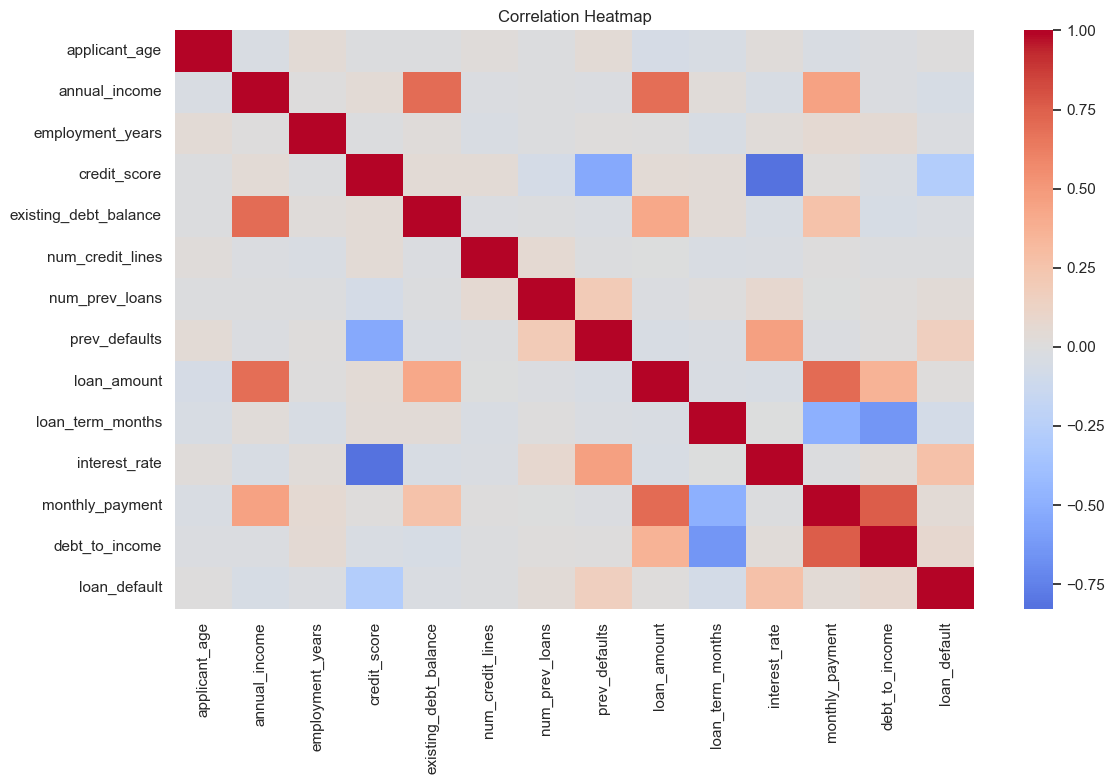

In [38]:
# ============================================================
# BUSINESS QUESTION:
# Which numeric variables are most strongly associated with default?
# ============================================================

corr_matrix = numeric_df.corr()

default_corr = (
    corr_matrix["loan_default"]
    .drop("loan_default")
    .abs()
    .sort_values(ascending=False)
)

top_3_features = default_corr.head(3)

print("\nTop 3 Features Correlated with Loan Default")
print(top_3_features)

corr_matrix = numeric_df.corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    annot=False
)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.savefig(
    "Correlation Heatmap.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()


In [39]:
# ============================================================
# BUSINESS QUESTION:
# Are applications increasing,decreasing or seasonal?
# ============================================================

monthly_apps = (
    df_clean
    .set_index("application_date")
    .resample("M")
    .size()
    .reset_index(name="applications")
)

C:\Users\nikde\AppData\Local\Temp\ipykernel_15384\1202941413.py:9: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")


In [40]:
monthly_apps 

,application_date,applications
0,2020-01-31,22
1,2020-02-29,16
2,2020-03-31,27
3,2020-04-30,20
4,2020-05-31,25
5,2020-06-30,19
6,2020-07-31,20
7,2020-08-31,14
8,2020-09-30,13
9,2020-10-31,23


C:\Users\nikde\anaconda3\envs\loan_ai\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\nikde\anaconda3\envs\loan_ai\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


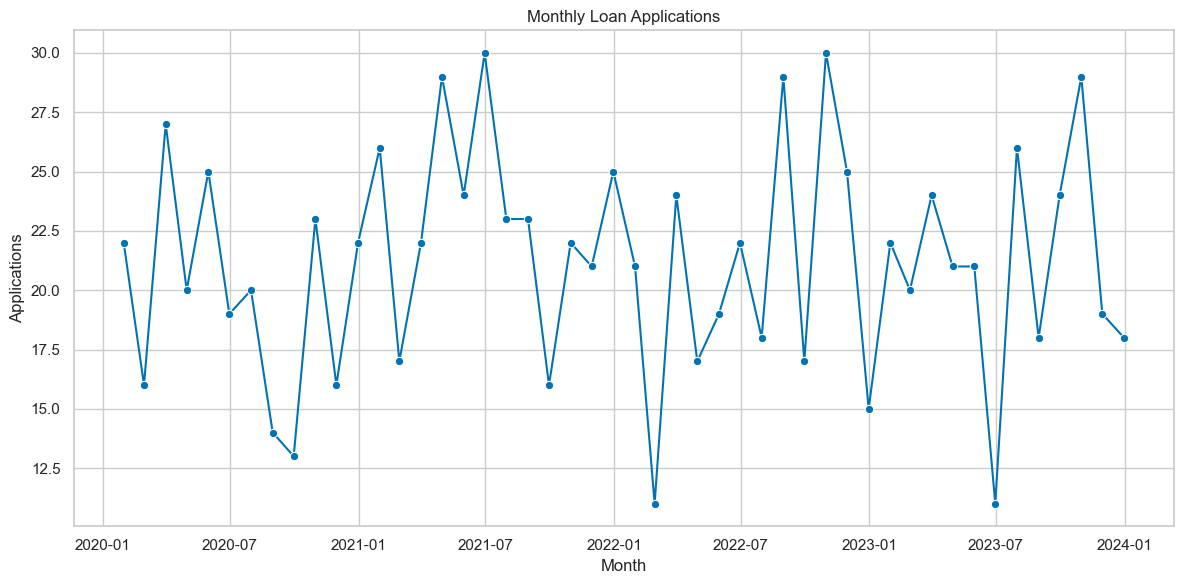

In [41]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=monthly_apps,
    x="application_date",
    y="applications",
    marker="o"
)

plt.title("Monthly Loan Applications")
plt.xlabel("Month")
plt.ylabel("Applications")

plt.tight_layout()

plt.savefig(
    "Monthly Loan Applications.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

  employment_type  default_rate_pct
0      Unemployed         57.142857
1   Self-Employed         43.258427
2       Part-Time         39.795918
3        Contract         34.453782
4        Salaried         34.369603


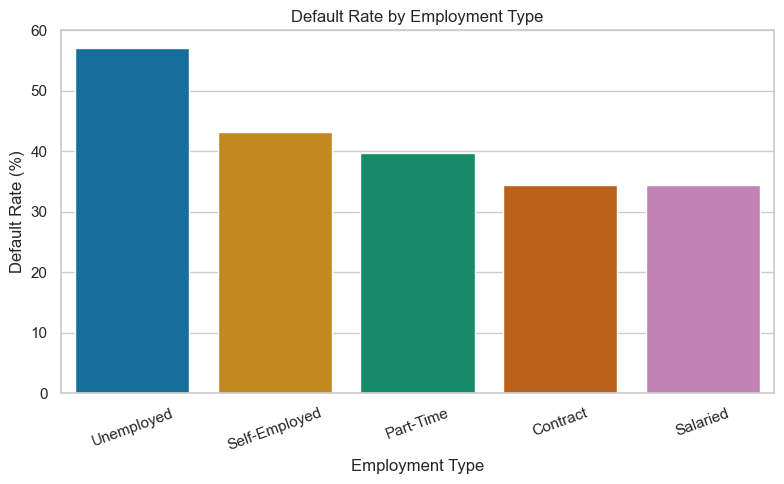

In [42]:
# ============================================================
# BUSINESS QUESTION:
# Which employment groups represent the highest risk?
# ============================================================

employment_default = default_rate_by_category(
    df_clean,
    "employment_type"
)

print(employment_default)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=employment_default,
    x="employment_type",
    y="default_rate_pct"
)

plt.title("Default Rate by Employment Type")
plt.xlabel("Employment Type")
plt.ylabel("Default Rate (%)")

plt.xticks(rotation=20)

plt.tight_layout()

plt.savefig(
    "Default Rate by Employment Type.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

  risk_grade  avg_loan_amount  avg_interest_rate
0          A    122575.639919           4.274228
1          B    116476.455549           5.005659
2          C    125769.302693           5.579257
3          D    102903.227366           6.113661
4          E    110232.495183           6.996646


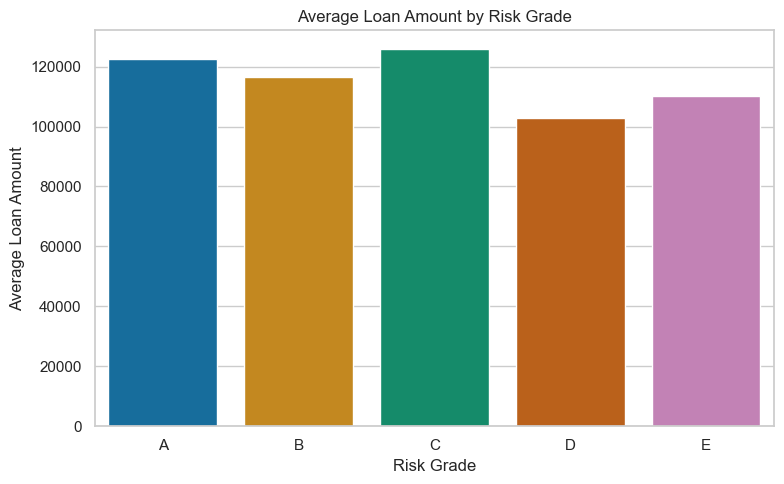

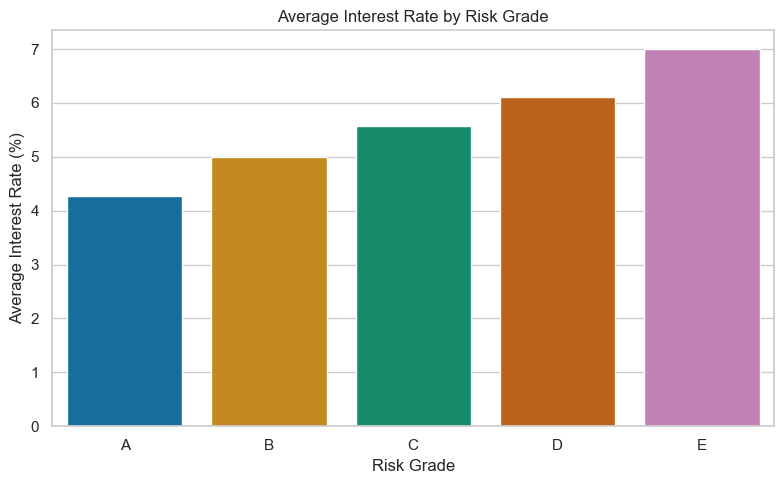

In [43]:
# ============================================================
# BUSINESS QUESTION:
# Are higher-risk borrowers being charged higher interest rates?
# ============================================================

grade_summary = (
    df_clean
    .groupby("risk_grade")
    .agg(
        avg_loan_amount=("loan_amount", "mean"),
        avg_interest_rate=("interest_rate", "mean")
    )
    .reset_index()
)

print(grade_summary)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=grade_summary,
    x="risk_grade",
    y="avg_loan_amount",
    order=["A", "B", "C", "D", "E"]
)

plt.title("Average Loan Amount by Risk Grade")
plt.xlabel("Risk Grade")
plt.ylabel("Average Loan Amount")

plt.tight_layout()

plt.savefig(
    "Average Loan Amount by Risk Grade.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

plt.figure(figsize=(8, 5))

sns.barplot(
    data=grade_summary,
    x="risk_grade",
    y="avg_interest_rate",
    order=["A", "B", "C", "D", "E"]
)

plt.title("Average Interest Rate by Risk Grade")
plt.xlabel("Risk Grade")
plt.ylabel("Average Interest Rate (%)")

plt.savefig(
    "Average Interest Rate by Risk Grade.png",
    dpi=150,
    bbox_inches="tight"
)

plt.tight_layout()
plt.show()

C:\Users\nikde\anaconda3\envs\loan_ai\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\nikde\anaconda3\envs\loan_ai\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\nikde\anaconda3\envs\loan_ai\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
C:\Users\nikde\anaconda3\envs\loan_ai\Lib\site-packages\seaborn\_oldc

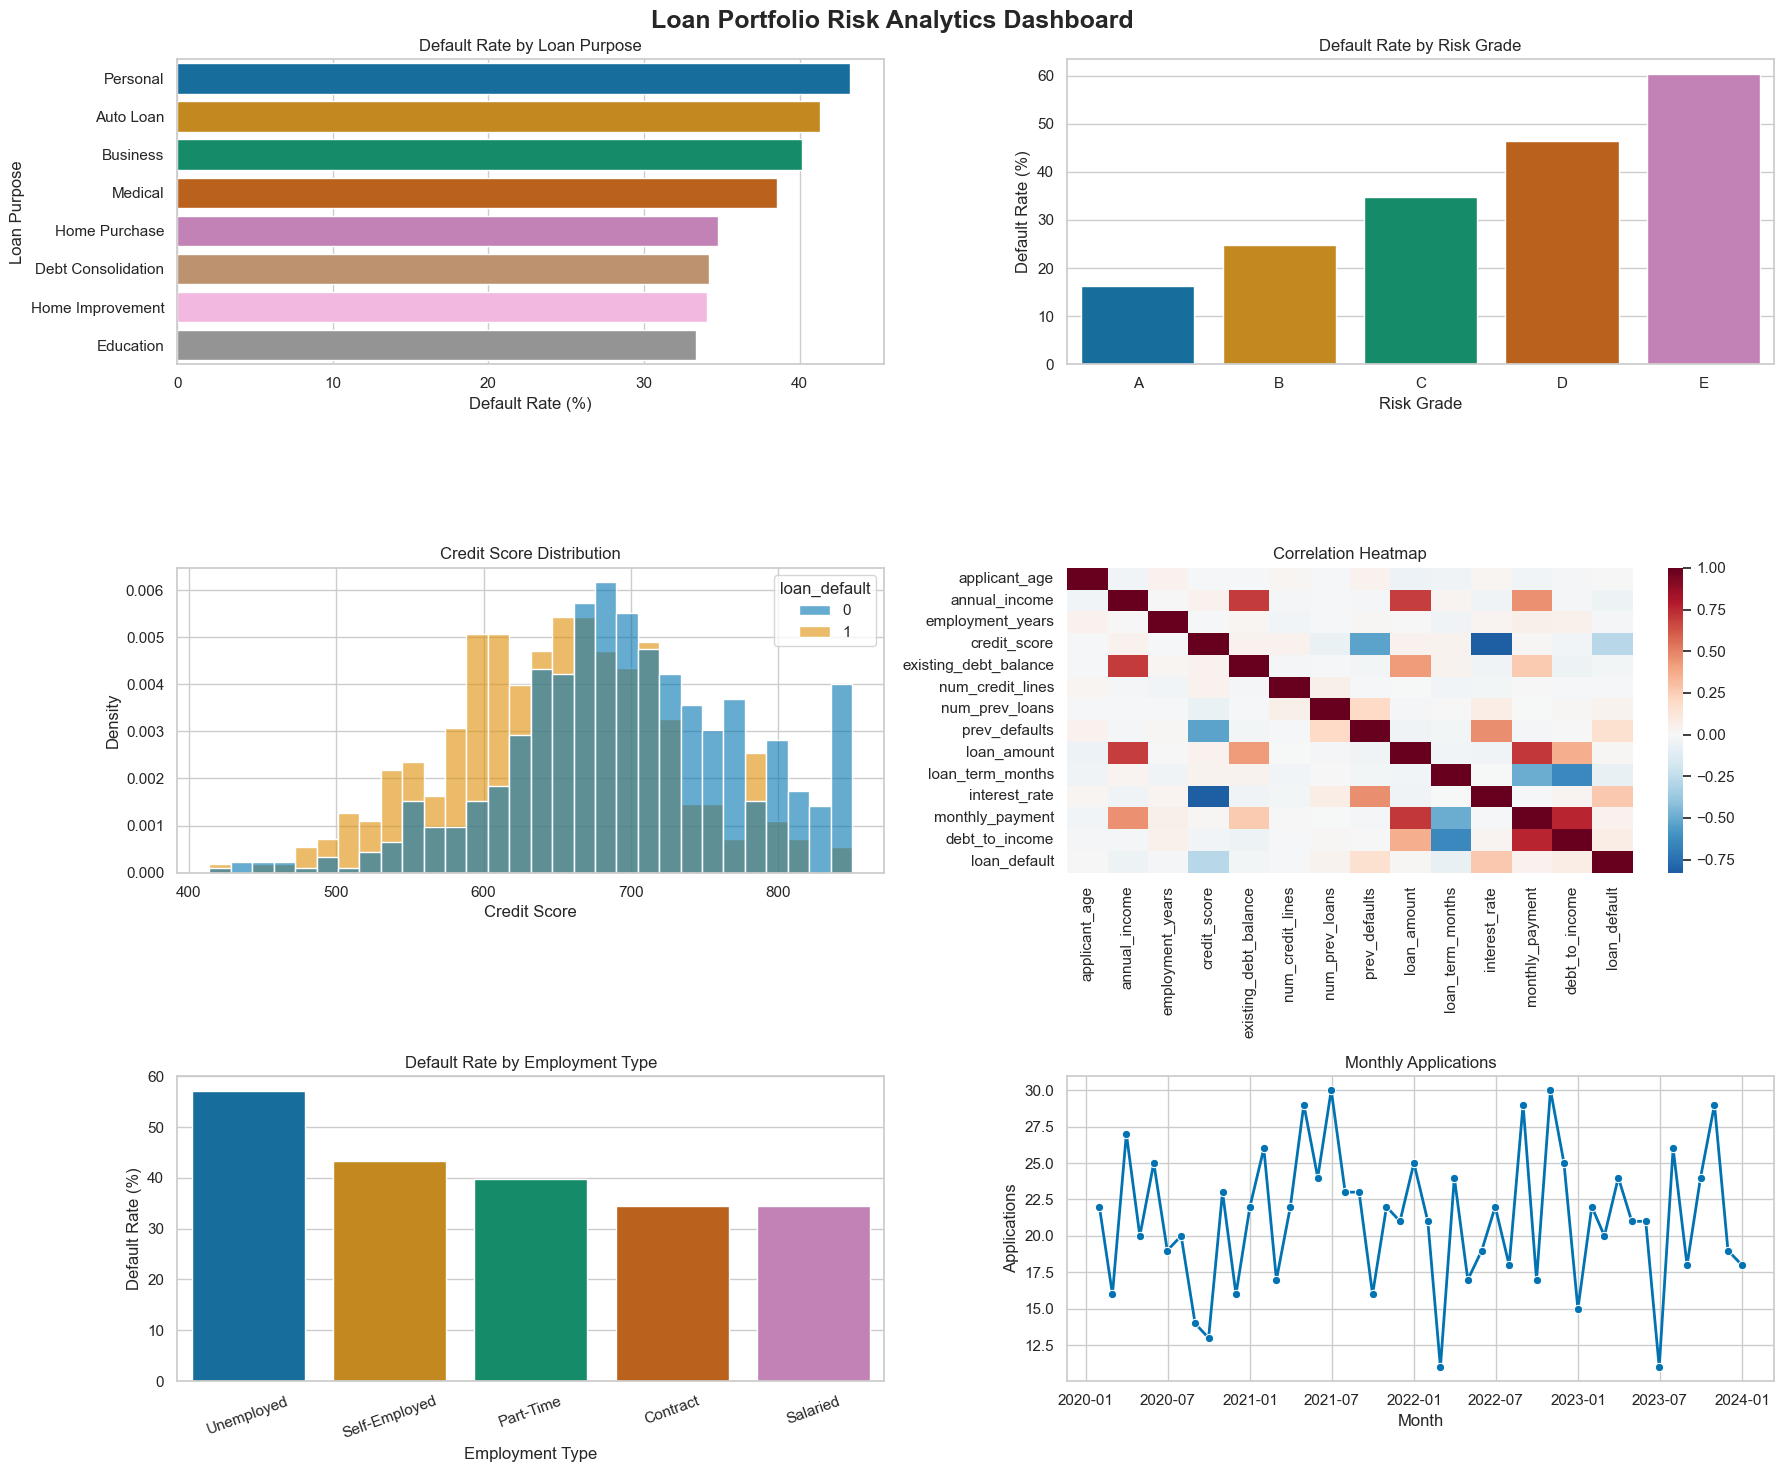

In [44]:
# ============================================================
# EDA DASHBOARD
# ============================================================

fig, axes = plt.subplots(
    3,
    2,
    figsize=(18, 15)
)

fig.suptitle(
    "Loan Portfolio Risk Analytics Dashboard",
    fontsize=18,
    fontweight="bold"
)

# ============================================================
# CHART 1
# Default Rate by Loan Purpose
# ============================================================

sns.barplot(
    data=purpose_default,
    x="default_rate_pct",
    y="loan_purpose",
    ax=axes[0,0]
)

axes[0,0].set_title(
    "Default Rate by Loan Purpose"
)

axes[0,0].set_xlabel(
    "Default Rate (%)"
)

axes[0,0].set_ylabel(
    "Loan Purpose"
)

# ============================================================
# CHART 2
# Default Rate by Risk Grade
# ============================================================

sns.barplot(
    data=grade_default,
    x="risk_grade",
    y="default_rate_pct",
    order=["A","B","C","D","E"],
    ax=axes[0,1]
)

axes[0,1].set_title(
    "Default Rate by Risk Grade"
)

axes[0,1].set_xlabel(
    "Risk Grade"
)

axes[0,1].set_ylabel(
    "Default Rate (%)"
)

# ============================================================
# CHART 3
# Credit Score Distribution
# ============================================================

sns.histplot(
    data=df_clean,
    x="credit_score",
    hue="loan_default",
    bins=30,
    stat="density",
    common_norm=False,
    alpha=0.6,
    ax=axes[1,0]
)

axes[1,0].set_title(
    "Credit Score Distribution"
)

axes[1,0].set_xlabel(
    "Credit Score"
)

axes[1,0].set_ylabel(
    "Density"
)

# ============================================================
# CHART 4
# Correlation Heatmap
# ============================================================

sns.heatmap(
    corr_matrix,
    cmap="RdBu_r",
    center=0,
    ax=axes[1,1]
)

axes[1,1].set_title(
    "Correlation Heatmap"
)

# ============================================================
# CHART 5
# Employment Risk
# ============================================================

sns.barplot(
    data=employment_default,
    x="employment_type",
    y="default_rate_pct",
    ax=axes[2,0]
)

axes[2,0].set_title(
    "Default Rate by Employment Type"
)

axes[2,0].set_xlabel(
    "Employment Type"
)

axes[2,0].set_ylabel(
    "Default Rate (%)"
)

axes[2,0].tick_params(
    axis="x",
    rotation=20
)

# ============================================================
# CHART 6
# Monthly Application Trend
# ============================================================

sns.lineplot(
    data=monthly_apps,
    x="application_date",
    y="applications",
    marker="o",
    linewidth=2,
    ax=axes[2,1]
)

axes[2,1].set_title(
    "Monthly Applications"
)

axes[2,1].set_xlabel(
    "Month"
)

axes[2,1].set_ylabel(
    "Applications"
)

# ============================================================
# EXPORT DASHBOARD
# ============================================================

plt.tight_layout()

plt.savefig(
    "eda_charts.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [45]:
# ============================================================
# KEY INSIGHT 1
# ============================================================
# Risk Grades D and E exhibit substantially higher
# default rates than Grades A and B.

# ============================================================
# KEY INSIGHT 2
# ============================================================
# Lower credit scores are associated with
# higher default probability.

# ============================================================
# KEY INSIGHT 3
# ============================================================
# Certain loan purposes consistently produce
# higher default rates and may require stricter
# underwriting criteria.

# ============================================================
# SURPRISING FINDING
# ============================================================
# To be completed after reviewing charts.

# ============================================================
# DATA LIMITATION
# ============================================================
# The dataset lacks collateral value,
# loan-to-value ratio and asset information.

In [46]:
# ============================================================
# BRANCH PERFORMANCE TABLE
# ============================================================

branch_performance = (
    df_clean
    .groupby("branch_id")
    .agg(
        total_applications=("application_id", "count"),
        total_loan_value=("loan_amount", "sum"),
        default_rate=("loan_default", "mean"),
        avg_credit_score=("credit_score", "mean")
    )
    .reset_index()
)

branch_performance["default_rate"] = (
    branch_performance["default_rate"] * 100
).round(2)

branch_performance["avg_credit_score"] = (
    branch_performance["avg_credit_score"]
).round(0)

print(branch_performance)

print("\nHighest Risk Branches")

print(
    branch_performance.sort_values(
        by="default_rate",
        ascending=False
    ).head()
)

   branch_id  total_applications  total_loan_value  default_rate  avg_credit_score
0     BR-001                  32        3665407.36         31.25             668.0
1     BR-002                  28        2844083.91         46.43             686.0
2     BR-003                  32        3959749.66         37.50             693.0
3     BR-004                  29        3308202.60         34.48             677.0
4     BR-005                  37        4331189.92         43.24             682.0
5     BR-006                  39        3496101.80         41.03             686.0
6     BR-007                  40        4617189.77         32.50             696.0
7     BR-008                  42        5523331.70         28.57             665.0
8     BR-009                  35        4652914.91         34.29             678.0
9     BR-010                  37        4018531.65         29.73             677.0
10    BR-011                  29        3861624.41         34.48             680.0
11  

In [47]:
# ============================================================
# DTI BAND ANALYSIS
# ============================================================

df_clean["DTI_Band"] = pd.cut(
    df_clean["debt_to_income"],
    bins=[0, 0.20, 0.35, 0.50, np.inf],
    labels=[
        "0-0.20",
        "0.20-0.35",
        "0.35-0.50",
        ">0.50"
    ]
)

dti_default = (
    df_clean
    .groupby("DTI_Band")["loan_default"]
    .mean()
    .mul(100)
    .reset_index(name="default_rate_pct")
)

print(dti_default)

    DTI_Band  default_rate_pct
0     0-0.20         26.153846
1  0.20-0.35         27.272727
2  0.35-0.50         34.693878
3      >0.50         43.247863


C:\Users\nikde\AppData\Local\Temp\ipykernel_15384\2917450943.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("DTI_Band")["loan_default"]


In [48]:
# ============================================================
# TARGET VARIABLE
# ============================================================

y = df_clean["loan_default"]

In [49]:
# ============================================================
# FEATURES
# ============================================================

X = df_clean.drop(
    columns=[
        "loan_default",
        "application_id",
        "application_date"
    ]
)

In [50]:
categorical_features = (
    X.select_dtypes(
        include=["object", "category"]
    ).columns
)

print(categorical_features)

Index(['branch_id', 'state', 'employment_type', 'loan_purpose', 'risk_grade', 'DTI_Band'], dtype='object')


In [51]:
# ============================================================
# TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [52]:
# ============================================================
# ONE-HOT ENCODING
# ============================================================

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ],
    remainder="passthrough"
)

In [53]:
# ============================================================
# LOGISTIC REGRESSION
# ============================================================

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),

        (
            "model",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

In [54]:
# Train Model
logistic_model.fit(
    X_train,
    y_train
)

C:\Users\nikde\anaconda3\envs\loan_ai\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['branch_id','state','applicant_age',...,'debt_to_income','risk_grade', 'DTI_Band']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all re

In [55]:
# Predictions
logistic_pred = logistic_model.predict(
    X_test
)

logistic_proba = (
    logistic_model.predict_proba(
        X_test
    )[:,1]
)

In [56]:
# ============================================================
# RANDOM FOREST
# ============================================================

rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),

        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                max_depth=8,
                random_state=42
            )
        )
    ]
)

In [57]:
# Train Model
rf_model.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](19,)","['branch_id','state','applicant_age',...,'debt_to_income','risk_grade', 'DTI_Band']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,19
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all re

In [58]:
# Predictions
rf_pred = rf_model.predict(
    X_test
)

rf_proba = (
    rf_model.predict_proba(
        X_test
    )[:,1]
)

In [59]:
# ============================================================
# MODEL EVALUATION
# ============================================================

def evaluate_model(
    model_name,
    y_true,
    y_pred,
    y_proba
):

    results = {
        "Model": model_name,

        "Accuracy":
            accuracy_score(
                y_true,
                y_pred
            ),

        "Precision":
            precision_score(
                y_true,
                y_pred
            ),

        "Recall":
            recall_score(
                y_true,
                y_pred
            ),

        "F1":
            f1_score(
                y_true,
                y_pred
            ),

        "ROC_AUC":
            roc_auc_score(
                y_true,
                y_proba
            )
    }

    return results

In [60]:
results = pd.DataFrame([

    evaluate_model(
        "Logistic Regression",
        y_test,
        logistic_pred,
        logistic_proba
    ),

    evaluate_model(
        "Random Forest",
        y_test,
        rf_pred,
        rf_proba
    )

])

print(results)

                 Model  Accuracy  Precision    Recall        F1   ROC_AUC
0  Logistic Regression  0.647059   0.541667  0.342105  0.419355  0.707545
1        Random Forest  0.661765   0.600000  0.276316  0.378378  0.725123


In [61]:
best_model = rf_model

y_proba = rf_proba

In [62]:
print(
    classification_report(
        y_test,
        rf_pred
    )
)

              precision    recall  f1-score   support

           0       0.67      0.89      0.77       128
           1       0.60      0.28      0.38        76

    accuracy                           0.66       204
   macro avg       0.64      0.58      0.57       204
weighted avg       0.65      0.66      0.62       204



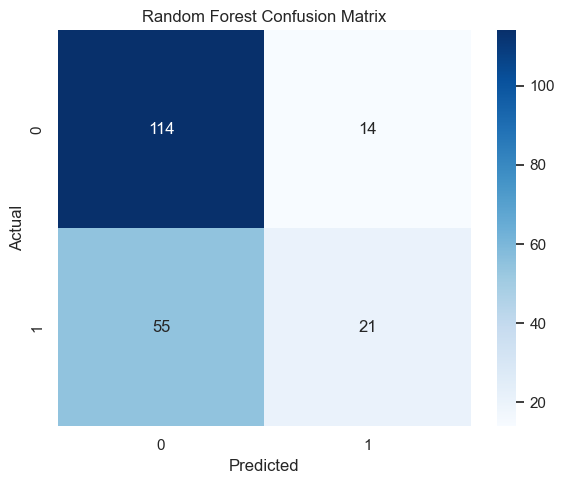

In [63]:
cm = confusion_matrix(
    y_test,
    rf_pred
)

plt.figure(
    figsize=(6,5)
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    "Random Forest Confusion Matrix"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.tight_layout()

plt.savefig(
    "confusion_matrix.png",
    dpi=150
)

plt.show()

In [64]:
## Evaluate Thresholds
thresholds = np.arange(
    0.05,
    1.00,
    0.05
)

threshold_results = []

In [65]:
for threshold in thresholds:

    y_pred_threshold = (
        y_proba >= threshold
    ).astype(int)

    precision = precision_score(
        y_test,
        y_pred_threshold
    )

    recall = recall_score(
        y_test,
        y_pred_threshold
    )

    f2 = fbeta_score(
        y_test,
        y_pred_threshold,
        beta=2
    )

    threshold_results.append(
        [
            threshold,
            precision,
            recall,
            f2
        ]
    )

C:\Users\nikde\anaconda3\envs\loan_ai\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\nikde\anaconda3\envs\loan_ai\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\nikde\anaconda3\envs\loan_ai\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\nikd

In [66]:
threshold_results = pd.DataFrame(
    threshold_results,
    columns=[
        "threshold",
        "precision",
        "recall",
        "f2_score"
    ]
)

print(threshold_results)

    threshold  precision    recall  f2_score
0        0.05   0.372549  1.000000  0.748031
1        0.10   0.372549  1.000000  0.748031
2        0.15   0.378109  1.000000  0.752475
3        0.20   0.385787  1.000000  0.758483
4        0.25   0.437870  0.973684  0.782241
5        0.30   0.470588  0.842105  0.727273
6        0.35   0.537736  0.750000  0.695122
7        0.40   0.567568  0.552632  0.555556
8        0.45   0.561404  0.421053  0.443213
9        0.50   0.600000  0.276316  0.309735
10       0.55   0.689655  0.263158  0.300300
11       0.60   0.684211  0.171053  0.201238
12       0.65   0.857143  0.078947  0.096463
13       0.70   1.000000  0.026316  0.032680
14       0.75   0.000000  0.000000  0.000000
15       0.80   0.000000  0.000000  0.000000
16       0.85   0.000000  0.000000  0.000000
17       0.90   0.000000  0.000000  0.000000
18       0.95   0.000000  0.000000  0.000000


In [67]:
best_threshold = (
    threshold_results
    .loc[
        threshold_results[
            "f2_score"
        ].idxmax(),
        "threshold"
    ]
)

print(
    f"Optimal Threshold: {best_threshold:.2f}"
)

Optimal Threshold: 0.25


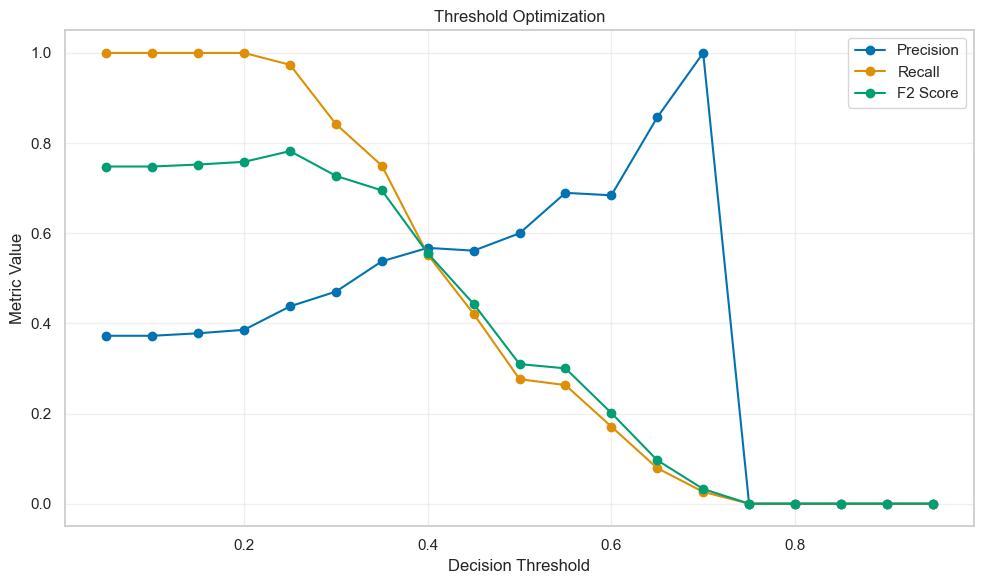

In [68]:
plt.figure(
    figsize=(10,6)
)

plt.plot(
    threshold_results["threshold"],
    threshold_results["precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_results["threshold"],
    threshold_results["recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_results["threshold"],
    threshold_results["f2_score"],
    marker="o",
    label="F2 Score"
)

plt.title(
    "Threshold Optimization"
)

plt.xlabel(
    "Decision Threshold"
)

plt.ylabel(
    "Metric Value"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    "threshold_tradeoff_curve.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [69]:
# ============================================================
# THRESHOLD OPTIMIZATION CONCLUSION
# ============================================================

# The bank prioritizes identifying potential defaulters
# rather than minimizing false alarms.

# Therefore Recall was selected as the primary metric.

# The default threshold of 0.50 was evaluated against
# multiple thresholds ranging from 0.05 to 0.95.

# The optimal threshold was selected using F2 Score,
# which places greater importance on Recall while still
# considering Precision.

# Lowering the threshold increased Recall and reduced
# missed defaulters, which aligns with the bank's
# business objective of minimizing credit losses.

In [70]:
# ============================================================
# CREATE WORKBOOK
# ============================================================

wb = Workbook()

In [71]:
default_sheet = wb.active

wb.remove(default_sheet)

In [72]:
# ============================================================
# EXECUTIVE SUMMARY
# ============================================================

ws = wb.create_sheet(
    title="Executive Summary"
)

ws["A1"] = "Loan Portfolio Risk Analytics Report"

ws["A1"].font = Font(
    bold=True,
    size=16
)

ws["A3"] = "Dataset Overview"

In [73]:
# Dataset Statistics
summary_data = [
    ["Metric", "Value"],
    ["Total Records", len(df_clean)],
    ["Total Defaults", df_clean["loan_default"].sum()],
    [
        "Default Rate (%)",
        round(
            df_clean["loan_default"].mean() * 100,
            2
        )
    ]
]

for row in summary_data:
    ws.append(row)

In [74]:
# Sheet 2 — Data Quality Audit

ws = wb.create_sheet(
    title="Data Quality Audit"
)

for row in quality_summary.itertuples(
    index=False
):
    ws.append(row)

In [75]:
ws = wb.create_sheet(
    title="Cleaning Summary"
)

ws.append(
    list(summary.columns)
)

for row in summary.values:
    ws.append(
        list(row)
    )

In [76]:
# Sheet 4 — EDA Insights
ws = wb.create_sheet(
    title="EDA Insights"
)

ws.append(
    ["Insight"]
)

In [77]:
insights = [

    "Risk Grade E exhibited the highest default rate.",

    "Lower credit scores were associated with higher default probability.",

    "Debt Consolidation loans showed elevated default rates.",

    "Certain branches demonstrated significantly higher default rates.",

    "Higher risk grades were charged higher interest rates."
]

for insight in insights:
    ws.append(
        [insight]
    )

In [78]:
# Sheet 5 — Branch Performance
ws = wb.create_sheet(
    title="Branch Performance"
)

ws.append(
    list(branch_performance.columns)
)

for row in branch_performance.values:
    ws.append(
        list(row)
    )

In [79]:
# Sheet 6 — Model Evaluation

ws = wb.create_sheet(
    title="Model Evaluation"
)

ws.append(
    list(results.columns)
)

for row in results.values:
    ws.append(
        list(row)
    )

In [80]:
# Sheet 7 — Threshold Optimization

ws = wb.create_sheet(
    title="Threshold Optimization"
)

ws.append(
    list(threshold_results.columns)
)

for row in threshold_results.values:
    ws.append(
        list(row)
    )

In [81]:
# ============================================================
# FORMAT ALL SHEETS
# ============================================================

header_fill = PatternFill(
    fill_type="solid",
    fgColor="D9EAD3"
)

header_font = Font(
    bold=True
)

In [82]:
for sheet in wb.worksheets:

    for cell in sheet[1]:

        cell.fill = header_fill

        cell.font = header_font

        cell.alignment = Alignment(
            horizontal="center"
        )

    for column in sheet.columns:

        max_length = 0

        column_letter = get_column_letter(
            column[0].column
        )

        for cell in column:

            try:

                max_length = max(
                    max_length,
                    len(str(cell.value))
                )

            except:

                pass

        sheet.column_dimensions[
            column_letter
        ].width = max_length + 2

In [83]:
# ============================================================
# SAVE REPORT
# ============================================================

report_file = (
    "loan_portfolio_analytics_report.xlsx"
)

wb.save(report_file)

print(
    f"Report saved successfully: {report_file}"
)

Report saved successfully: loan_portfolio_analytics_report.xlsx


In [84]:
# ============================================================
# SURPRISING FINDING
# ============================================================

# Although lower credit scores were associated with higher
# default rates, a noticeable proportion of high-credit-score
# borrowers still defaulted. This suggests that credit score
# alone is insufficient for risk assessment and should be
# supplemented with additional factors such as debt burden
# and prior default history.

In [85]:
# check if .env exists
print(os.path.abspath(".env"))
print(os.path.exists(".env"))

C:\Users\nikde\Documents\Grow Data Skills\Class 10\.env
True


In [86]:
# Load .env
load_dotenv()

# Read API Key
GOOGLE_API_KEY = os.getenv("GOOGLE_API_KEY")

# Set environment variable for LangChain
os.environ["GOOGLE_API_KEY"] = GOOGLE_API_KEY

if not GOOGLE_API_KEY:
    raise ValueError(
        "GOOGLE_API_KEY not found. Please create a .env file with your Gemini API key."
    )

In [87]:
llm = LiteLLM(
    model="gemini/gemini-2.5-flash",
    api_key=GOOGLE_API_KEY
)

In [88]:
llm

In [89]:
sdf = SmartDataframe(
    df_clean,
    config={"llm": llm}
)

C:\Users\nikde\AppData\Local\Temp\ipykernel_15384\1681112016.py:1: DeprecationWarning: 
********************************************************************************
DEPRECATION WARNING:
SmartDataframe will soon be deprecated. Please use df.chat() instead.
********************************************************************************

  sdf = SmartDataframe(


In [90]:
response = sdf.chat(
    "Show top 10 applications by revenue")

response.value

,application_id,total_interest_revenue
0,APP-000144,96685.96
1,APP-000060,74849.47
2,APP-000084,72383.09
3,APP-000910,61492.18
4,APP-000327,61102.65
5,APP-000449,60893.92
6,APP-000441,58860.00
7,APP-000530,57522.10
8,APP-000641,57157.08
9,APP-000789,57132.56


In [91]:
response = sdf.chat(
    "What is the average loan amount by loan purpose?")

response.value.round(2)

,loan_purpose,average_loan_amount
0,Personal,113960.01
1,Home Improvement,112596.64
2,Debt Consolidation,120814.45
3,Education,119234.42
4,Home Purchase,92276.76
5,Business,131708.70
6,Auto Loan,118440.29
7,Medical,117322.20


In [92]:
sdf.chat(
    "Show monthly revenue trend")

# print(response)

DataFrameResponse(type='dataframe', value=      month  total_monthly_revenue
0   2020-01              119074.51
1   2020-02               45619.39
2   2020-03              151038.82
3   2020-04               73928.41
4   2020-05              108837.83
5   2020-06               49102.63
6   2020-07               70123.44
7   2020-08               60025.48
8   2020-09               64589.46
9   2020-10              147699.72
10  2020-11               81009.96
11  2020-12               73358.64
12  2021-01              112135.53
13  2021-02               64215.32
14  2021-03              107930.70
15  2021-04              109946.77
16  2021-05               89191.65
17  2021-06               97556.00
18  2021-07              136721.11
19  2021-08              113654.50
20  2021-09               89659.95
21  2021-10              110985.31
22  2021-11              109004.82
23  2021-12              105472.02
24  2022-01              176001.76
25  2022-02               54206.21
26  2022-03  

In [93]:
response = sdf.chat(
    "Which risk segment contributes the most revenue?")

response.value

,risk_grade,total_revenue
0,C,1605048.58


In [94]:
response = sdf.chat(
    "Identify the top 5 factors associated with loan default")

response.value

,factor,default_rate_percent
0,Risk Grade: E,60.365852
1,Has Previous Defaults,57.894737
2,Employment Type: Unemployed,57.142857
3,Low Credit Score (<650),53.372433
4,High Interest Rate (>6%),50.797871


In [95]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_experimental.agents import create_pandas_dataframe_agent

llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0
)

agent = create_pandas_dataframe_agent(
    llm=llm,
    df=df_clean,  # your final dataframe
    verbose=True,
    allow_dangerous_code=True
)

In [96]:
print(langchain.__version__)

1.3.11


In [97]:
print(langchain_experimental.__version__)

0.4.2


In [98]:
print(importlib.metadata.version("langchain-experimental"))

0.4.2


In [99]:
print(importlib.metadata.version("langchain"))
print(importlib.metadata.version("langchain-core"))
print(importlib.metadata.version("langchain-experimental"))

1.3.11
1.4.8
0.4.2


In [100]:
# ==========================================
# Conversational Wrapper
# ==========================================

conversation_history = []


def ask_agent(question):

    global conversation_history

    history = "\n".join(conversation_history)

    prompt = f"""
You are analysing a pandas dataframe called df.

Previous conversation:
{history}

Current question:
{question}

If the current question refers to previous answers using words like:
- those
- them
- previous
- that group
- those borrowers
- those customers

then use the previous conversation to resolve the reference before generating Python code.
"""

    response = agent.invoke({"input": prompt})

    answer = response["output"]

    conversation_history.append(f"User: {question}")
    conversation_history.append(f"Assistant: {answer}")

    return answer

In [101]:
print(ask_agent(
    "Which employment type has the highest default rate?"
))



> Entering new AgentExecutor chain...
Action: python_repl_ast
Action Input:
default_rates = df.groupby('employment_type')['loan_default'].mean()
highest_default_employment_type = default_rates.idxmax()
print(highest_default_employment_type)Unemployed
I now know the final answer
Final Answer: Unemployed

> Finished chain.
Unemployed


In [102]:
print(ask_agent(
    "What is the average loan amount for those borrowers?"
))



> Entering new AgentExecutor chain...
Action: python_repl_ast
Action Input: print(df[df['employment_type'] == 'Unemployed']['loan_amount'].mean())121893.5345238095
I now know the final answer
Final Answer: 121893.53

> Finished chain.
121893.53


In [103]:
print(ask_agent(
    "How many such borrowers are there?"
))



> Entering new AgentExecutor chain...
Action: python_repl_ast
Action Input: print(df[df['employment_type'] == 'Unemployed'].shape[0])42
I now know the final answer
Final Answer: 42

> Finished chain.
42


In [104]:
print("=" * 60)
print("Loan Analytics Chatbot")
print("Type 'exit' to quit")
print("=" * 60)

while True:

    question = input("\nYou: ").strip()

    if question.lower() == "exit":
        print("Goodbye!")
        break

    answer = ask_agent(question)

    print("\nAssistant:")
    print(answer)

Loan Analytics Chatbot
Type 'exit' to quit



You:  exit


Goodbye!
